In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", "{:.2f}".format)

RANDOM_STATE = 42


## 1. Find and Load the Data
 function that load the data from csv locally and from kaggle. 


In [3]:
DATA_CANDIDATES = [
    Path.cwd() / "data",
    Path.cwd().parent / "data",
    Path("/kaggle/input/datasets/anasnofal/uk-police-crime-dataset-mar-2023-feb-2025"),
    Path("/kaggle/input/uk-police-crime-dataset-mar-2023-feb-2025"),
]

DATA_DIR = next((path for path in DATA_CANDIDATES if (path / "all_street.csv").exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Could not find all_street.csv. Check DATA_CANDIDATES or your data folder.")

paths = {
    "street": DATA_DIR / "all_street.csv",
    "outcomes": DATA_DIR / "all_outcomes.csv",
    "stop_search": DATA_DIR / "all_stop_and_search.csv",
}

print(f"Using data directory: {DATA_DIR}")
for name, path in paths.items():
    print(f"{name:12s}: {path}")


Using data directory: /Users/anas/PythonProjects/CBL/data
street      : /Users/anas/PythonProjects/CBL/data/all_street.csv
outcomes    : /Users/anas/PythonProjects/CBL/data/all_outcomes.csv
stop_search : /Users/anas/PythonProjects/CBL/data/all_stop_and_search.csv


In [4]:
def missing_table(frame: pd.DataFrame) -> pd.DataFrame:
    """Return missing value counts and percentages by column."""
    missing = frame.isna().sum().sort_values(ascending=False)
    return (
        pd.DataFrame({"missing_count": missing, "missing_percent": missing / len(frame) * 100})
        .reset_index(names="column")
    )


def top_counts(frame: pd.DataFrame, column: str, n: int = 15) -> pd.DataFrame:
    """Return top values with counts and percentages."""
    values = frame[column].astype("string").fillna("Missing")
    counts = values.value_counts(dropna=False).head(n)
    result = counts.rename_axis(column).reset_index(name="count")
    result["percent"] = result["count"] / len(frame) * 100
    return result


def plot_top_counts(table: pd.DataFrame, label_col: str, value_col: str = "count", title: str = "") -> None:
    plt.figure(figsize=(12, max(5, 0.35 * len(table))))
    sns.barplot(data=table, x=value_col, y=label_col, palette="viridis")
    plt.title(title)
    plt.xlabel(value_col.replace("_", " ").title())
    plt.ylabel(label_col.replace("_", " ").title())
    plt.tight_layout()
    plt.show()


## 2. Street Crime Data



In [5]:
df = pd.read_csv(paths["street"], parse_dates=["Month"])

for col in ["source_file", "Reported by", "Falls within", "Crime type", "Last outcome category"]:
    if col in df.columns:
        df[col] = df[col].astype("category")

for col in ["Longitude", "Latitude"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Street rows: {len(df):,}")
print(f"Street columns: {df.shape[1]:,}")


Street rows: 17,880,940
Street columns: 13


In [6]:
display(df.head())
display(df.sample(min(5, len(df)), random_state=RANDOM_STATE))


,source_file,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
0,2023-03-avon-and-somerset-street.csv,a9e67112895dee54af5fdfb03b1196df2ade54ef9a4562...,2023-03-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.49,51.42,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Violence and sexual offences,Unable to prosecute suspect,NaN
1,2023-03-avon-and-somerset-street.csv,2e8a39786d327a0ee5012c937c73d345727f17fd778f34...,2023-03-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.51,51.42,On or near Durley Lane,E01014399,Bath and North East Somerset 001A,Public order,Formal action is not in the public interest,NaN
2,2023-03-avon-and-somerset-street.csv,55e85c975222172afd8b520ffad3c7e0d7505e773ec65f...,2023-03-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.49,51.42,On or near Trajectus Way,E01014399,Bath and North East Somerset 001A,Public order,Unable to prosecute suspect,NaN
3,2023-03-avon-and-somerset-street.csv,29c72e6199b0302cb152846c59372d366d97db9ee3aeba...,2023-03-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.51,51.41,On or near Harlech Close,E01014399,Bath and North East Somerset 001A,Violence and sexual offences,Unable to prosecute suspect,NaN
4,2023-03-avon-and-somerset-street.csv,6f44ecaeff6df6efe60b06305a34b092792dd012cbd5da...,2023-03-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,-2.51,51.42,On or near St Francis Road,E01014399,Bath and North East Somerset 001A,Violence and sexual offences,Unable to prosecute suspect,NaN


,source_file,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,Context
8850007,2024-08-lancashire-street.csv,NaN,2024-08-01,Lancashire Constabulary,Lancashire Constabulary,-2.21,53.84,On or near Sussex Street,E01025182,Pendle 009B,Anti-social behaviour,NaN,NaN
9060511,2024-08-south-yorkshire-street.csv,8529dccb61a3168da3ee8a161f049feea2065476695f2d...,2024-08-01,South Yorkshire Police,South Yorkshire Police,-1.23,53.60,On or near Straight Lane,E01007587,Doncaster 020C,Burglary,Investigation complete; no suspect identified,NaN
9914612,2024-10-metropolitan-street.csv,NaN,2024-10-01,Metropolitan Police Service,Metropolitan Police Service,-0.08,51.40,On or near St Dunstan'S Road,E01001136,Croydon 007A,Anti-social behaviour,NaN,NaN
3341002,2023-09-lancashire-street.csv,74f948010812a3958cf9add5184d4e8f55cb3f3eb231f5...,2023-09-01,Lancashire Constabulary,Lancashire Constabulary,-2.70,53.70,On or near Yewlands Drive,E01025422,South Ribble 013B,Violence and sexual offences,Local resolution,NaN
16011869,2025-10-suffolk-street.csv,6ebdc076ef9aa9ee4086e4fbae241f4dece87c412e4d49...,2025-10-01,Suffolk Constabulary,Suffolk Constabulary,0.62,52.44,On or near Petrol Station,E01029929,West Suffolk 002D,Shoplifting,Investigation complete; no suspect identified,NaN


In [7]:
street_overview = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [df.shape[1]],
        "memory_mb_estimate": [df.memory_usage(index=True, deep=False).sum() / 1_000_000],
        "start_month": [df["Month"].min()],
        "end_month": [df["Month"].max()],
        "months": [df["Month"].nunique()],
        "police_forces": [df["Reported by"].nunique()],
        "crime_types": [df["Crime type"].nunique()],
        "lsoa_codes": [df["LSOA code"].nunique()],
    },
    index=["street_crime"],
)

display(street_overview.T.rename(columns={"street_crime": "value"}))


,value
rows,17880940
columns,13
memory_mb_estimate,1251.68
start_month,2023-03-01 00:00:00
end_month,2026-02-01 00:00:00
months,36
police_forces,44
crime_types,14
lsoa_codes,35746


In [8]:
df.info(show_counts=True, memory_usage="deep")


<class 'pandas.DataFrame'>
RangeIndex: 17880940 entries, 0 to 17880939
Data columns (total 13 columns):
 #   Column                 Non-Null Count     Dtype         
---  ------                 --------------     -----         
 0   source_file            17880940 non-null  category      
 1   Crime ID               14941617 non-null  str           
 2   Month                  17880940 non-null  datetime64[us]
 3   Reported by            17880940 non-null  category      
 4   Falls within           17880940 non-null  category      
 5   Longitude              17614301 non-null  float64       
 6   Latitude               17614301 non-null  float64       
 7   Location               17880940 non-null  str           
 8   LSOA code              17190446 non-null  str           
 9   LSOA name              17190446 non-null  str           
 10  Crime type             17880940 non-null  category      
 11  Last outcome category  14650247 non-null  category      
 12  Context                

### Data Quality Checks



,column,missing_count,missing_percent
0,Context,17880940,100.00
1,Last outcome category,3230693,18.07
2,Crime ID,2939323,16.44
3,LSOA code,690494,3.86
4,LSOA name,690494,3.86
5,Longitude,266639,1.49
6,Latitude,266639,1.49
7,source_file,0,0.00
8,Month,0,0.00
9,Reported by,0,0.00


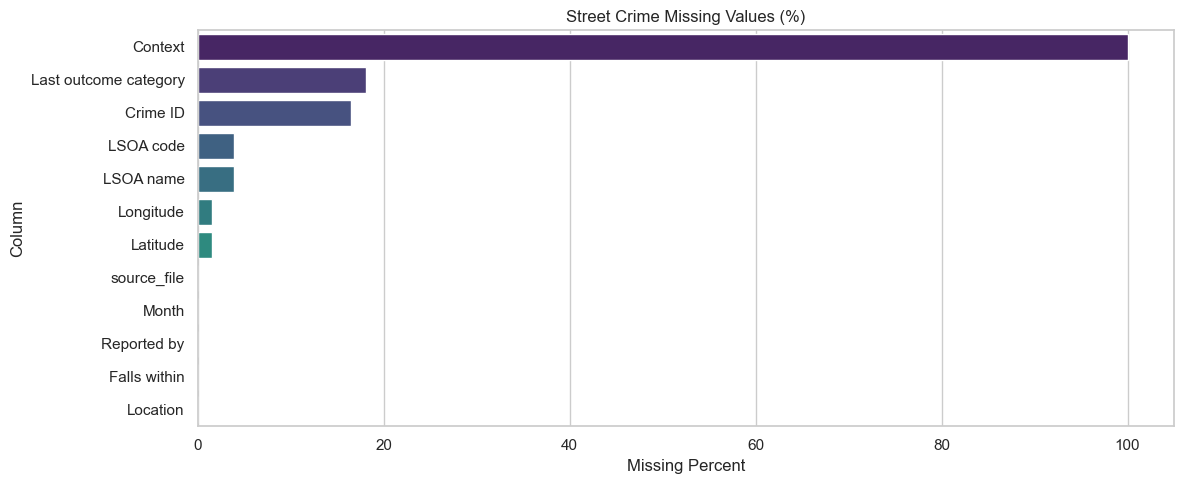

In [9]:
street_missing = missing_table(df)
display(street_missing)

plot_top_counts(
    street_missing.head(12),
    label_col="column",
    value_col="missing_percent",
    title="Street Crime Missing Values (%)",
)


In [10]:
crime_id = df["Crime ID"].astype("string")
valid_geo = df["Latitude"].between(49, 61) & df["Longitude"].between(-9, 3)

quality_checks = pd.DataFrame(
    {
        "check": [
            "missing_crime_id",
            "duplicate_crime_id_excluding_missing",
            "rows_with_coordinates",
            "rows_with_valid_uk_coordinates",
            "rows_without_lsoa_code",
        ],
        "count": [
            crime_id.isna().sum(),
            crime_id[crime_id.notna()].duplicated().sum(),
            df[["Latitude", "Longitude"]].notna().all(axis=1).sum(),
            valid_geo.sum(),
            df["LSOA code"].isna().sum(),
        ],
    }
)
quality_checks["percent_of_rows"] = quality_checks["count"] / len(df) * 100

display(quality_checks)



,check,count,percent_of_rows
0,missing_crime_id,2939323,16.44
1,duplicate_crime_id_excluding_missing,357979,2.00
2,rows_with_coordinates,17614301,98.51
3,rows_with_valid_uk_coordinates,17614301,98.51
4,rows_without_lsoa_code,690494,3.86


so many missing crime id with some duplicates !, this will cause problem when we want to merge the data with other datasets. We will have to drop those rows with missing crime id, which will result in loss of data.


small number of missing coordinated , and all are in the UK. 

### Crime Type Distribution



,Crime type,count,percent
0,Violence and sexual offences,6191286,34.63
1,Anti-social behaviour,2860534,16.00
2,Shoplifting,1400668,7.83
3,Criminal damage and arson,1346395,7.53
4,Other theft,1280690,7.16
5,Public order,1257838,7.03
6,Vehicle crime,991129,5.54
7,Burglary,699796,3.91
8,Drugs,563432,3.15
9,Other crime,369493,2.07


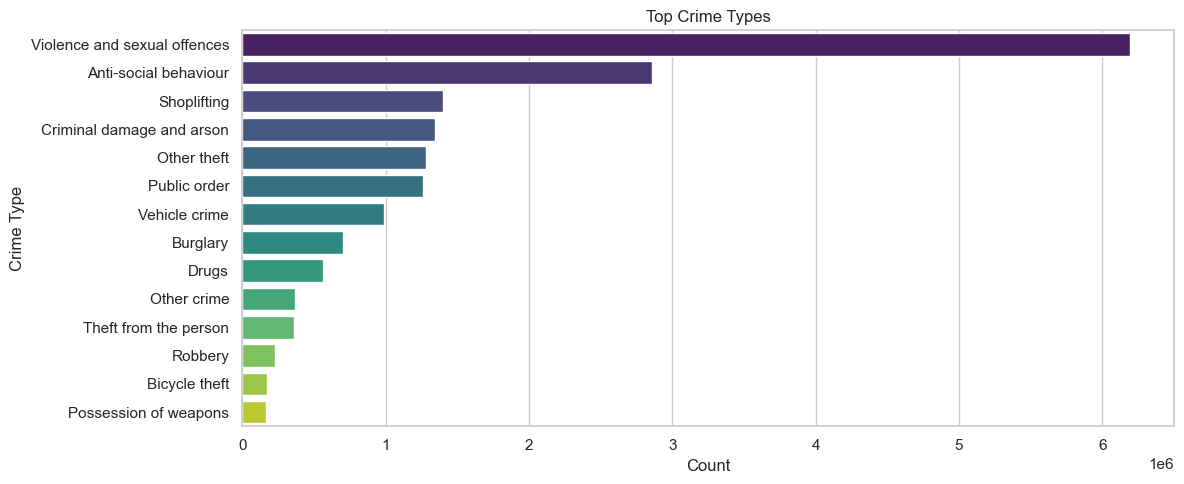

In [11]:
crime_type_counts = top_counts(df, "Crime type")
display(crime_type_counts)
plot_top_counts(crime_type_counts, "Crime type", title="Top Crime Types")


violence and sexual offences are the most common crime types in the dataset, followed by anti-social behaviour and criminal damage.

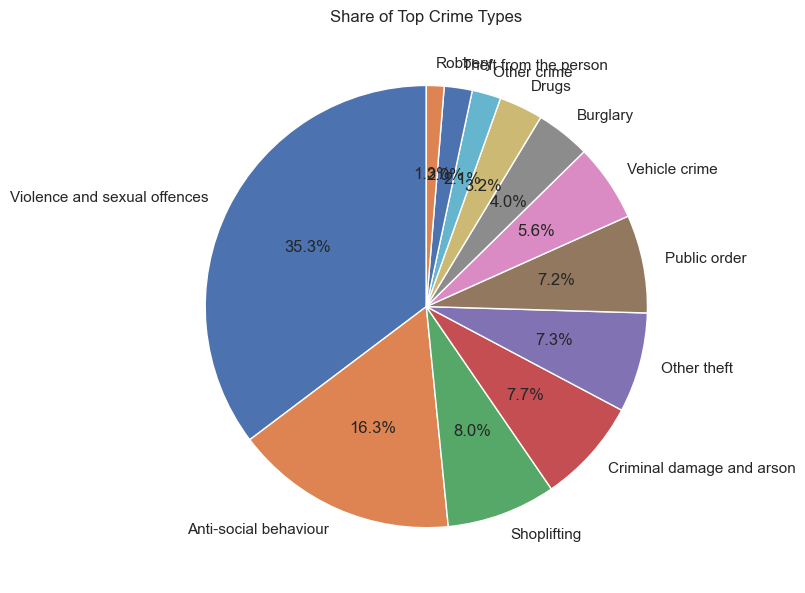

In [12]:
crime_type_share = crime_type_counts.set_index("Crime type")["percent"].head(12)

plt.figure(figsize=(8, 8))
plt.pie(crime_type_share, labels=crime_type_share.index, autopct="%1.1f%%", startangle=90)
plt.title("Share of Top Crime Types")
plt.tight_layout()
plt.show()


### Time Trends

Monthly counts reveal seasonality, unusual peaks, and changes over time. Because this dataset covers two years, year-over-year comparisons are possible for the second year.


,Month,crime_count,month_over_month_pct,year_over_year_pct
0,2023-03-01,526084,NaN,NaN
1,2023-04-01,511229,-2.82,NaN
2,2023-05-01,535333,4.71,NaN
3,2023-06-01,544532,1.72,NaN
4,2023-07-01,533581,-2.01,NaN
5,2023-08-01,520941,-2.37,NaN
6,2023-09-01,514173,-1.30,NaN
7,2023-10-01,522786,1.68,NaN
8,2023-11-01,480849,-8.02,NaN
9,2023-12-01,462518,-3.81,NaN


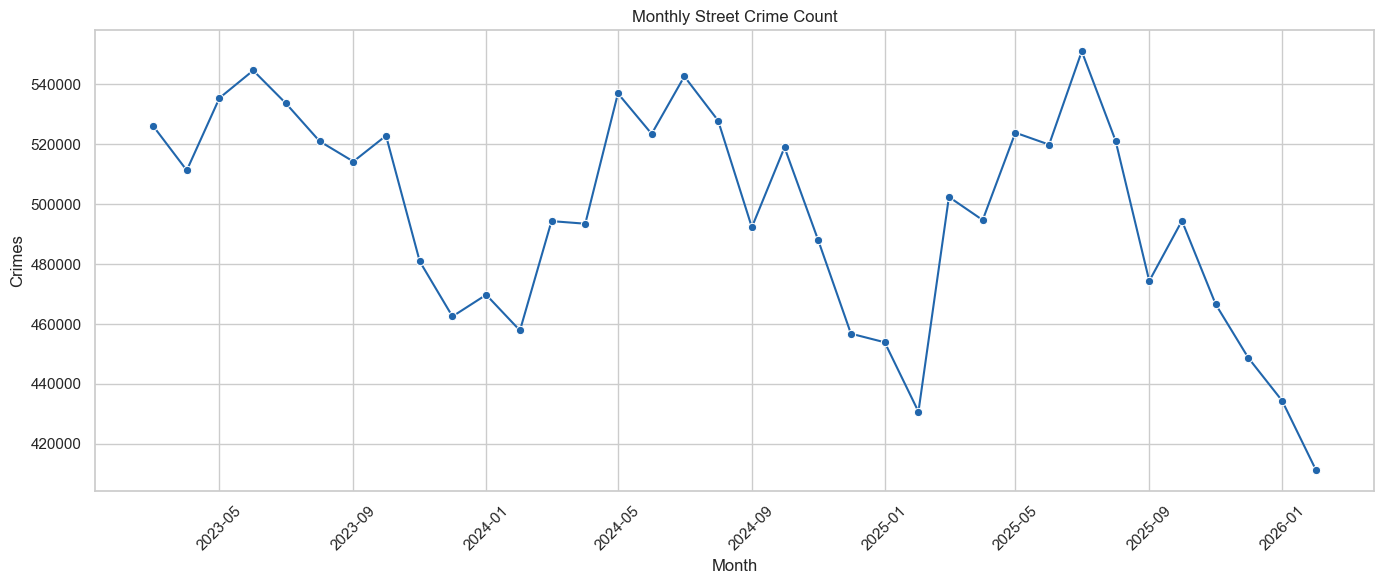

In [13]:
monthly_counts = (
    df.dropna(subset=["Month"])
    .groupby(pd.Grouper(key="Month", freq="MS"), observed=True)
    .size()
    .rename("crime_count")
    .reset_index()
    .sort_values("Month")
)
monthly_counts["month_over_month_pct"] = monthly_counts["crime_count"].pct_change() * 100
monthly_counts["year_over_year_pct"] = monthly_counts["crime_count"].pct_change(12) * 100

display(monthly_counts)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_counts, x="Month", y="crime_count", marker="o", color="#2166ac")
plt.title("Monthly Street Crime Count")
plt.xlabel("Month")
plt.ylabel("Crimes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


we can see a clear seasonal pattern with peaks in the spring and summer months and decline in the winter months. 

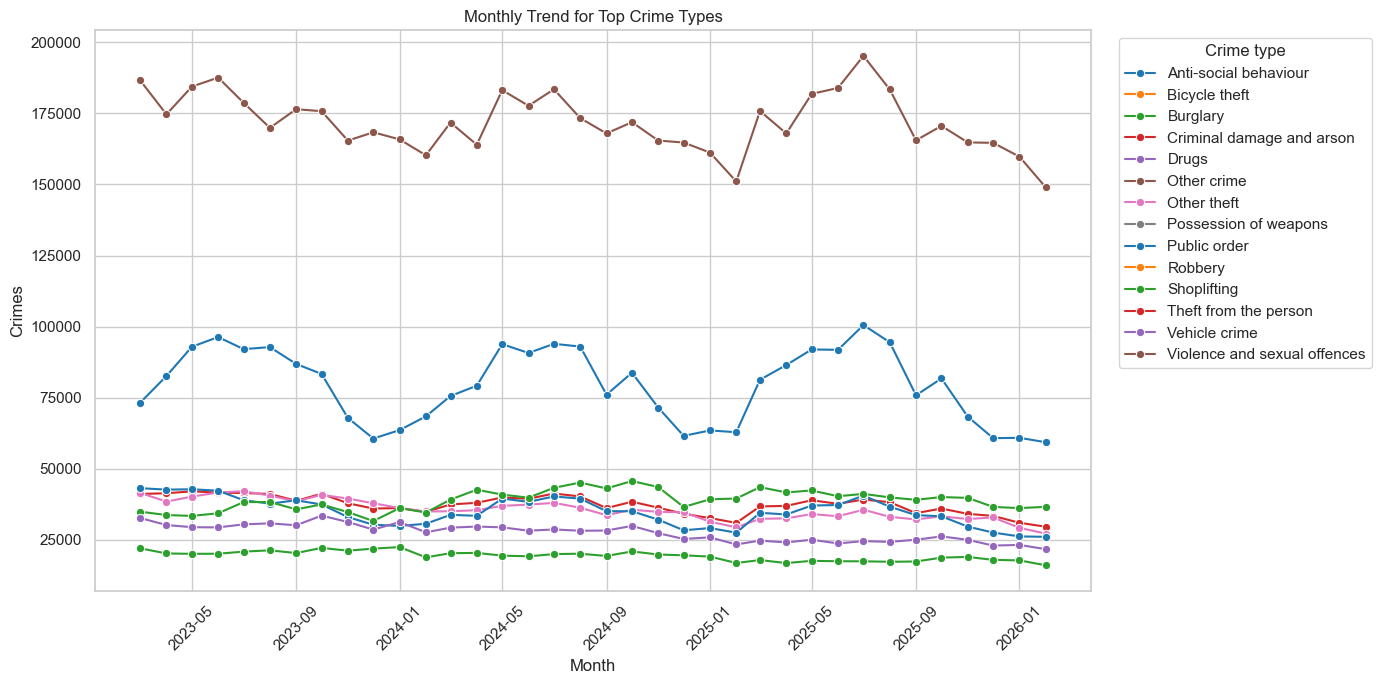

In [14]:
top_crime_types = df["Crime type"].astype("string").value_counts().head(8).index
palette = sns.color_palette("tab10", n_colors=len(top_crime_types))
monthly_type_counts = (
    df[df["Crime type"].astype("string").isin(top_crime_types)]
    .groupby([pd.Grouper(key="Month", freq="MS"), "Crime type"], observed=True)
    .size()
    .rename("crime_count")
    .reset_index()
)

plt.figure(figsize=(14, 7))
sns.lineplot(data=monthly_type_counts, x="Month", y="crime_count", hue="Crime type", palette=palette, marker="o")
plt.title("Monthly Trend for Top Crime Types")
plt.xlabel("Month")
plt.ylabel("Crimes")
plt.xticks(rotation=45)
plt.legend(title="Crime type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

here we can see that the seasonality is more obvious in in violent and sexual offense crime and anti-social behavior,  In contrast, the seasonality is less pronounced in other crime types, which may be influenced by a wider range of factors beyond just weather and daylight hours.

,Month,crime_count,month_over_month_pct,year_over_year_pct
24,2025-03,502362,16.62,1.63
25,2025-04,494657,-1.53,0.25
26,2025-05,523788,5.89,-2.44
27,2025-06,519810,-0.76,-0.68
28,2025-07,550909,5.98,1.54
29,2025-08,521168,-5.40,-1.26
30,2025-09,474338,-8.99,-3.64
31,2025-10,494406,4.23,-4.72
32,2025-11,466564,-5.63,-4.37
33,2025-12,448696,-3.83,-1.77


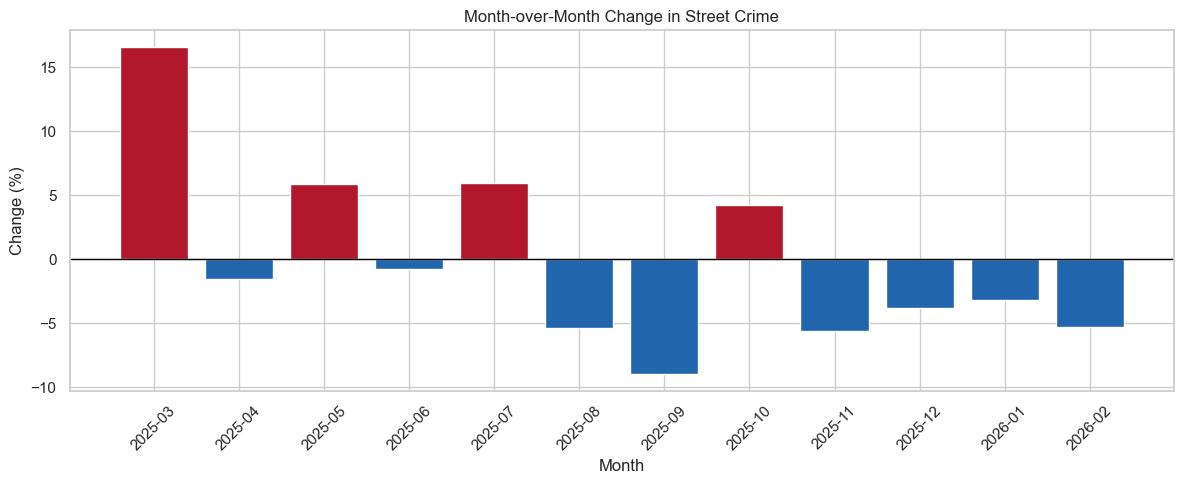

In [15]:
monthly_change = monthly_counts.tail(12).copy()
monthly_change["Month"] = monthly_change["Month"].dt.strftime("%Y-%m")

display(monthly_change[["Month", "crime_count", "month_over_month_pct", "year_over_year_pct"]])

colors = np.where(monthly_change["month_over_month_pct"].fillna(0) >= 0, "#b2182b", "#2166ac")
plt.figure(figsize=(12, 5))
plt.bar(monthly_change["Month"], monthly_change["month_over_month_pct"], color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.title("Month-over-Month Change in Street Crime")
plt.xlabel("Month")
plt.ylabel("Change (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


it has an average of high increase in march, this continue though the spring and summer months, then it decline in the winter months.

### Police Force and Local Area Patterns




In [43]:
for force in df["Reported by"].unique():
    print(force)

Avon and Somerset Constabulary
Bedfordshire Police
British Transport Police
Cambridgeshire Constabulary
Cheshire Constabulary
City of London Police
Cleveland Police
Cumbria Constabulary
Derbyshire Constabulary
Devon & Cornwall Police
Dorset Police
Durham Constabulary
Dyfed-Powys Police
Essex Police
Gloucestershire Constabulary
Gwent Police
Hampshire Constabulary
Hertfordshire Constabulary
Humberside Police
Kent Police
Lancashire Constabulary
Leicestershire Police
Lincolnshire Police
Merseyside Police
Metropolitan Police Service
Norfolk Constabulary
North Wales Police
North Yorkshire Police
Northamptonshire Police
Police Service of Northern Ireland
Northumbria Police
Nottinghamshire Police
South Wales Police
South Yorkshire Police
Staffordshire Police
Suffolk Constabulary
Surrey Police
Sussex Police
Thames Valley Police
Warwickshire Police
West Mercia Police
West Midlands Police
West Yorkshire Police
Wiltshire Police


,Reported by,count,percent
0,Metropolitan Police Service,3415852,19.10
1,West Midlands Police,1016771,5.69
2,West Yorkshire Police,931689,5.21
3,Thames Valley Police,594801,3.33
4,Avon and Somerset Constabulary,565647,3.16
5,Kent Police,554760,3.10
6,Lancashire Constabulary,544805,3.05
7,South Yorkshire Police,530231,2.97
8,Northumbria Police,515425,2.88
9,Hampshire Constabulary,509657,2.85


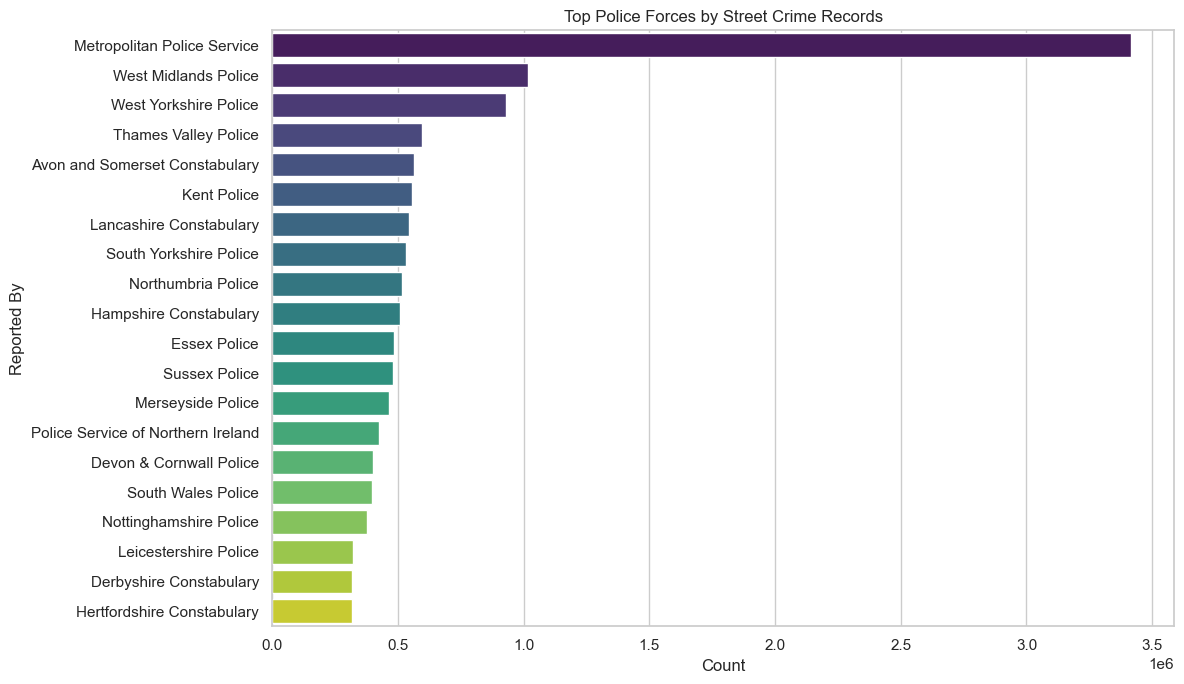

In [17]:
force_counts = top_counts(df, "Reported by", n=20)
display(force_counts)
plot_top_counts(force_counts, "Reported by", title="Top Police Forces by Street Crime Records")


In [18]:
top_lsoa = (
    df.groupby(["LSOA code", "LSOA name"], dropna=False, observed=True)
    .size()
    .rename("crime_count")
    .reset_index()
    .sort_values("crime_count", ascending=False)
    .head(25)
)

top_locations = (
    df.groupby(["LSOA name", "Location"], dropna=False, observed=True)
    .size()
    .rename("crime_count")
    .reset_index()
    .sort_values("crime_count", ascending=False)
    .head(25)
)

print("Top LSOAs")
display(top_lsoa)
print("Top location labels")
display(top_locations)

Top LSOAs


,LSOA code,LSOA name,crime_count
37856,NaN,NaN,690494
35732,E01035716,Westminster 013G,42465
4698,E01004763,Westminster 013B,32980
4671,E01004734,Westminster 018A,31434
33106,E01033010,Leeds 111B,23303
32826,E01032739,City of London 001F,21882
4673,E01004736,Westminster 018C,19550
33713,E01033620,Birmingham 138A,17405
37835,W01002019,Cardiff 032H,17144
2428,E01002444,Hillingdon 031A,16750


Top location labels


,LSOA name,Location,crime_count
722865,NaN,No Location,266639
722866,NaN,On or near,58692
415900,Newham 039D,On or near Shopping Area,6992
685075,Westminster 013B,On or near Nightclub,6912
684854,Westminster 011B,On or near Shopping Area,5789
685062,Westminster 013B,On or near Further/Higher Educational Building,5352
305876,Hillingdon 031A,On or near Shopping Area,4824
190779,Dartford 006D,On or near Shopping Area,4812
305808,Hillingdon 031A,On or near Bedfont Court,4548
685256,Westminster 013G,On or near Nightclub,4363


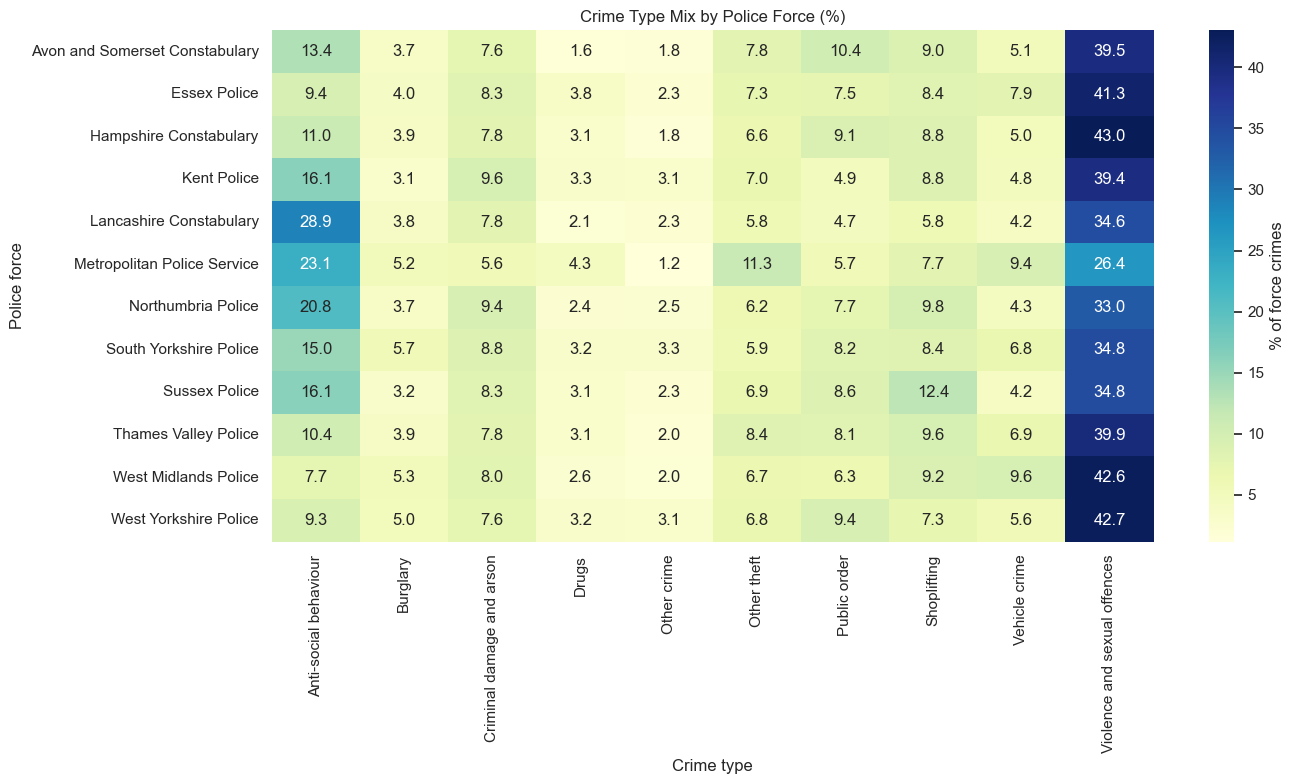

In [19]:
top_forces = df["Reported by"].astype("string").value_counts().head(12).index
top_types = df["Crime type"].astype("string").value_counts().head(10).index

force_crime = (
    df[
        df["Reported by"].astype("string").isin(top_forces)
        & df["Crime type"].astype("string").isin(top_types)
    ]
    .groupby(["Reported by", "Crime type"], observed=True)
    .size()
    .unstack(fill_value=0)
)
force_crime_pct = force_crime.div(force_crime.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 8))
sns.heatmap(force_crime_pct, cmap="YlGnBu", annot=True, fmt=".1f", cbar_kws={"label": "% of force crimes"})
plt.title("Crime Type Mix by Police Force (%)")
plt.xlabel("Crime type")
plt.ylabel("Police force")
plt.tight_layout()
plt.show()


notice that Metropolitan police , which has the highest number of crimes, has a fair ditribution of crime types, with violence and sexual offences being the most common, followed by anti-social behaviour and criminal damage. In contrast, some police forces have a more skewed distribution, with one or two crime types dominating the data. For example, in the West Midlands police force, violence and sexual offences account for a much higher proportion of crimes compared to other types. T

### Spatial Patterns



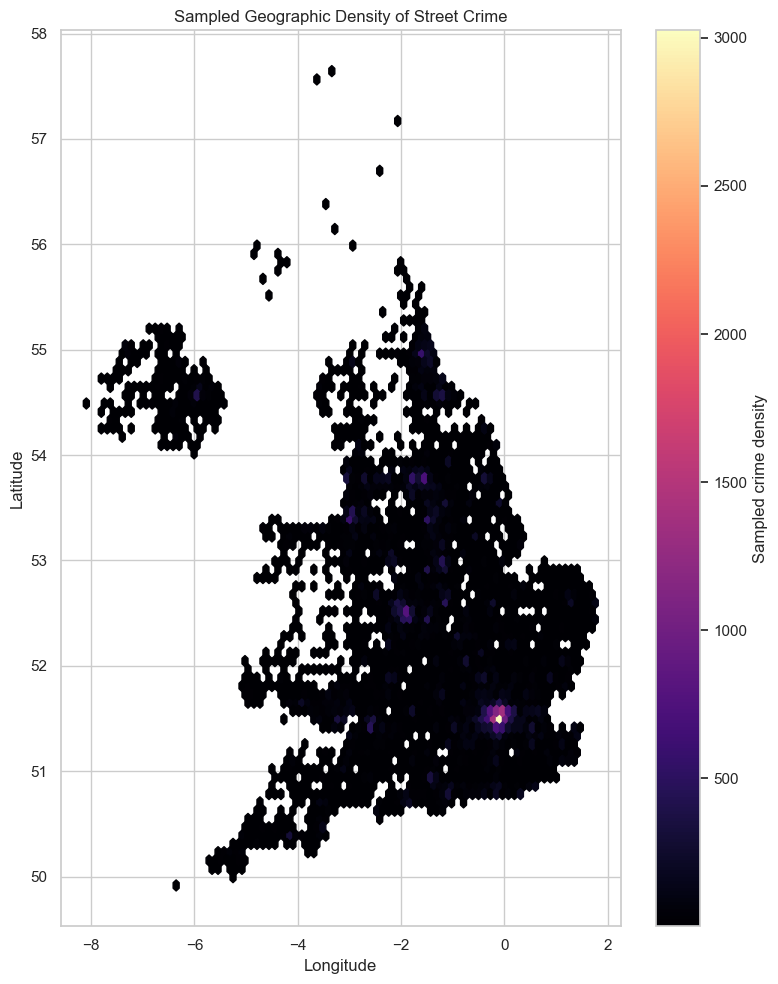

In [20]:
geo_df = df.loc[valid_geo, ["Longitude", "Latitude", "Crime type", "Month"]].dropna(subset=["Longitude", "Latitude"])
geo_sample = geo_df.sample(min(75_000, len(geo_df)), random_state=RANDOM_STATE)

plt.figure(figsize=(8, 10))
plt.hexbin(geo_sample["Longitude"], geo_sample["Latitude"], gridsize=85, cmap="magma", mincnt=1)
plt.colorbar(label="Sampled crime density")
plt.title("Sampled Geographic Density of Street Crime")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


In [46]:
police_stations = pd.read_csv("../data/force_representative_locations.csv")
police_stations.head()

,Force,Station,Latitude,Longitude,Operator,Police,Postcode,Match_Source,Match_Keyword
0,Avon and Somerset Constabulary,Avon & Somerset Police Headquarters,51.48,-2.79,Avon and Somerset Police,NaN,NaN,Operator,avon and somerset
1,Bedfordshire Police,Bedfordshire Police Headquarters,52.11,-0.50,Bedfordshire Police,NaN,MK43 9AX,Operator,bedfordshire
2,British Transport Police,British Transport Police Force Headquarters,51.54,-0.14,British Transport Police,NaN,NW1 9LN,Operator,british transport
3,Cambridgeshire Constabulary,Ely Police Station,52.40,0.26,Cambridgeshire Constabulary,NaN,NaN,Operator,cambridgeshire
4,Cheshire Constabulary,Cheshire Police Headquarters,53.19,-2.56,NaN,NaN,NaN,Station,cheshire


In [47]:
import folium
from folium.plugins import HeatMap, MarkerCluster
from pathlib import Path

map_sample = geo_df.sample(min(25_000, len(geo_df)), random_state=RANDOM_STATE)
center = [map_sample["Latitude"].mean(), map_sample["Longitude"].mean()]

crime_map = folium.Map(location=center, zoom_start=6, tiles="CartoDB positron")

HeatMap(
    map_sample[["Latitude", "Longitude"]].values.tolist(),
    radius=7,
    blur=5,
    name="Crime heatmap",
).add_to(crime_map)

stations = police_stations.dropna(subset=["Latitude", "Longitude"])

station_layer = MarkerCluster(name="Police stations").add_to(crime_map)

for _, row in stations.iterrows():
    folium.Marker(
        location=[row["Latitude"], row["Longitude"]],
        tooltip=row["Station"],
        popup=folium.Popup(f"<b>{row['Station']}</b>", max_width=250),
        icon=folium.Icon(color="blue", icon="info-sign"),
    ).add_to(station_layer)

folium.LayerControl().add_to(crime_map)

output_dir = Path("eda_outputs")
output_dir.mkdir(exist_ok=True)

map_path = output_dir / "street_crime_heatmap_sample.html"
crime_map.save(map_path)

print(f"Saved sampled heatmap to: {map_path}")
crime_map

Saved sampled heatmap to: eda_outputs/street_crime_heatmap_sample.html


### Street Crime Outcomes




,Last outcome category,count,percent
0,Investigation complete; no suspect identified,5728213,32.04
1,Unable to prosecute suspect,5363552,30.00
2,Missing,3230693,18.07
3,Status update unavailable,1019624,5.70
4,Court result unavailable,824152,4.61
5,Under investigation,456820,2.55
6,Local resolution,414785,2.32
7,Awaiting court outcome,281394,1.57
8,Action to be taken by another organisation,200585,1.12
9,Offender given a caution,114147,0.64


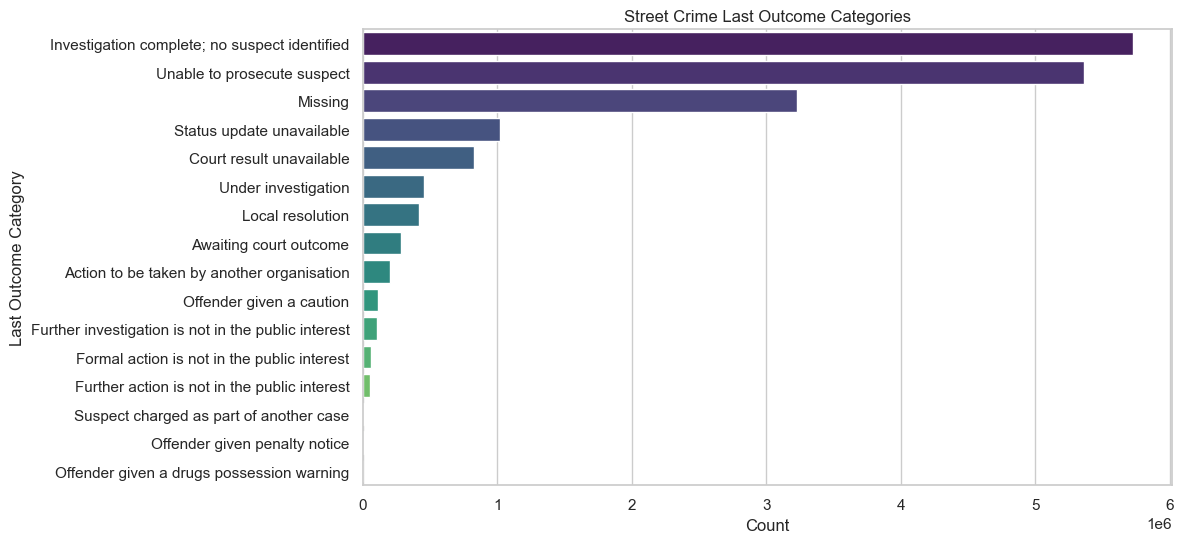

In [22]:
street_outcome_counts = top_counts(df, "Last outcome category", n=20)
display(street_outcome_counts)
plot_top_counts(street_outcome_counts, "Last outcome category", title="Street Crime Last Outcome Categories")


In [23]:
outcome_by_crime = pd.crosstab(
    df["Crime type"].astype("string"),
    df["Last outcome category"].astype("string").fillna("Missing"),
)
outcome_rates_by_crime = outcome_by_crime.div(outcome_by_crime.sum(axis=1), axis=0) * 100

interesting_outcomes = [
    "Unable to prosecute suspect",
    "Investigation complete; no suspect identified",
    "Under investigation",
    "Suspect charged",
    "Local resolution",
    "Missing",  # it means the data is missing, not that the outcome is "Missing"
]
existing_outcomes = [col for col in interesting_outcomes if col in outcome_rates_by_crime.columns]

display(outcome_rates_by_crime[existing_outcomes].round(1).sort_values(existing_outcomes[0], ascending=False))

Last outcome category,Unable to prosecute suspect,Investigation complete; no suspect identified,Under investigation,Local resolution,Missing
Crime type,,,,,
Violence and sexual offences,56.10,16.40,3.90,2.00,2.50
Public order,43.50,31.60,2.70,2.20,1.50
Other crime,36.00,16.90,5.10,1.90,2.90
Possession of weapons,32.60,11.70,4.30,4.00,3.10
Robbery,25.50,51.90,4.40,0.40,1.80
Criminal damage and arson,24.90,55.10,1.90,2.30,3.80
Other theft,18.70,67.50,1.90,0.80,2.90
Drugs,15.40,9.80,4.40,28.30,4.90
Shoplifting,14.70,52.80,2.20,2.90,2.00


## 3. Exploratory Forecasting




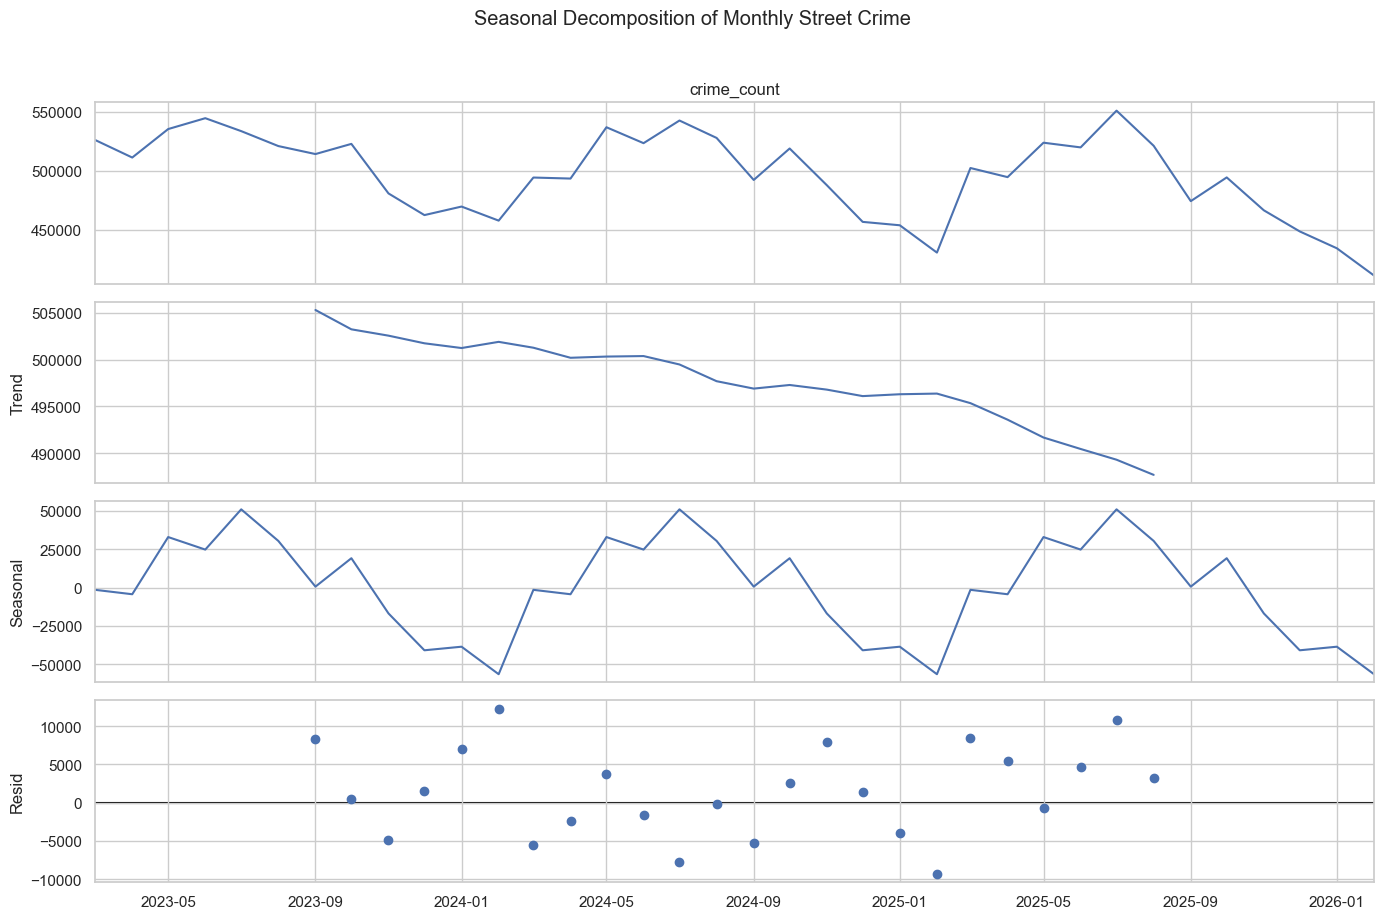

In [24]:
from itertools import product
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

ts = monthly_counts.set_index("Month")["crime_count"].sort_index().asfreq("MS").fillna(0)

if len(ts) >= 24:
    decomposition = seasonal_decompose(ts, model="additive", period=12)
    fig = decomposition.plot()
    fig.set_size_inches(14, 9)
    fig.suptitle("Seasonal Decomposition of Monthly Street Crime", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Need at least 24 monthly observations for a 12-month seasonal decomposition.")


In [25]:
p = range(0, 3)
d = range(0, 2)
q = range(0, 3)
seasonal_p = range(0, 2)
seasonal_d = range(0, 2)
seasonal_q = range(0, 2)
seasonal_period = 12

best_aic = np.inf
best_order = None
best_seasonal = None
best_res = None

for order in product(p, d, q):
    for seasonal in product(seasonal_p, seasonal_d, seasonal_q):
        seasonal_order = (*seasonal, seasonal_period)
        try:
            model = SARIMAX(
                ts,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            result = model.fit(disp=False)
            if result.aic < best_aic:
                best_aic = result.aic
                best_order = order
                best_seasonal = seasonal_order
                best_res = result
        except Exception:
            continue

print(f"Best SARIMA{best_order}x{best_seasonal} - AIC={best_aic:.2f}")


/Users/anas/PythonProjects/CBL/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/anas/PythonProjects/CBL/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/anas/PythonProjects/CBL/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/anas/PythonProjects/CBL/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/a

Best SARIMA(2, 1, 2)x(0, 1, 1, 12) - AIC=176.78


/Users/anas/PythonProjects/CBL/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


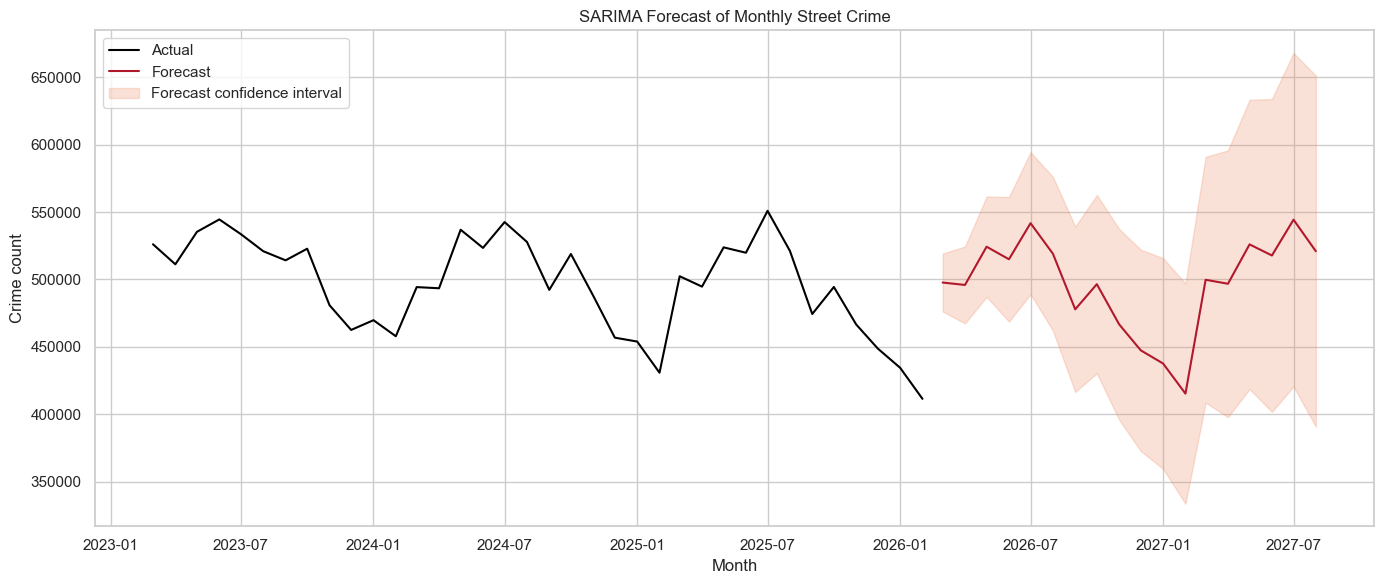

In [26]:
forecast_steps = 18
prediction = best_res.get_prediction(start=ts.index[0], end=ts.index[-1])
predicted_mean = prediction.predicted_mean
forecast = best_res.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

plt.figure(figsize=(14, 6))
plt.plot(ts, label="Actual", color="black")
plt.plot(forecast_mean, label="Forecast", color="#b2182b")
plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    color="#ef8a62",
    alpha=0.25,
    label="Forecast confidence interval",
)
plt.title("SARIMA Forecast of Monthly Street Crime")
plt.xlabel("Month")
plt.ylabel("Crime count")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Outcomes Data




In [27]:
df_outcome = pd.read_csv(paths["outcomes"], parse_dates=["Month"])

for col in ["source_file", "Reported by", "Falls within", "Outcome type"]:
    if col in df_outcome.columns:
        df_outcome[col] = df_outcome[col].astype("category")

for col in ["Longitude", "Latitude"]:
    df_outcome[col] = pd.to_numeric(df_outcome[col], errors="coerce")

print(f"Outcome rows: {len(df_outcome):,}")
print(f"Outcome columns: {df_outcome.shape[1]:,}")


Outcome rows: 14,382,853
Outcome columns: 11


In [28]:
display(df_outcome.head())

outcome_overview = pd.DataFrame(
    {
        "rows": [len(df_outcome)],
        "columns": [df_outcome.shape[1]],
        "start_month": [df_outcome["Month"].min()],
        "end_month": [df_outcome["Month"].max()],
        "months": [df_outcome["Month"].nunique()],
        "police_forces": [df_outcome["Reported by"].nunique()],
        "outcome_types": [df_outcome["Outcome type"].nunique()],
    },
    index=["outcomes"],
)

display(outcome_overview.T.rename(columns={"outcomes": "value"}))


,source_file,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Outcome type
0,2023-03-avon-and-somerset-outcomes.csv,ebebcee2cef8318a153e6571edf04ab74147b316d0509d...,2023-03-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Suspect charged
1,2023-03-avon-and-somerset-outcomes.csv,ad7ff5fad01e92b579021600843bb0845371c512448d1e...,2023-03-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Unable to prosecute suspect
2,2023-03-avon-and-somerset-outcomes.csv,a0d8cecfcc350fd66ef536bae255a5a9baa6d79435b542...,2023-03-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Unable to prosecute suspect
3,2023-03-avon-and-somerset-outcomes.csv,af6852e3c44a14e1a40586004b02635b92d47ba7b45cbb...,2023-03-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Unable to prosecute suspect
4,2023-03-avon-and-somerset-outcomes.csv,65877db6939f63634198519a68739db2392a623012ccf5...,2023-03-01,Avon and Somerset Constabulary,Avon and Somerset Constabulary,NaN,NaN,No location,NaN,NaN,Unable to prosecute suspect


,value
rows,14382853
columns,11
start_month,2023-03-01 00:00:00
end_month,2026-02-01 00:00:00
months,36
police_forces,42
outcome_types,12


,column,missing_count,missing_percent
0,LSOA code,219298,1.52
1,LSOA name,219298,1.52
2,Longitude,219277,1.52
3,Latitude,219277,1.52
4,source_file,0,0.00
5,Crime ID,0,0.00
6,Month,0,0.00
7,Reported by,0,0.00
8,Falls within,0,0.00
9,Location,0,0.00


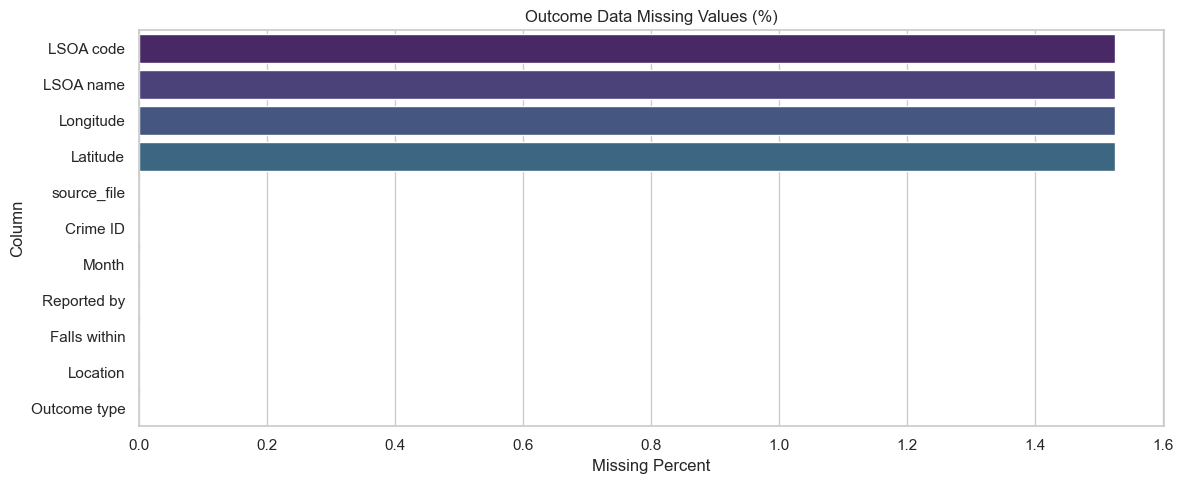

In [29]:
outcome_missing = missing_table(df_outcome)
display(outcome_missing)
plot_top_counts(outcome_missing.head(12), "column", "missing_percent", "Outcome Data Missing Values (%)")


,Outcome type,count,percent
0,Investigation complete; no suspect identified,6160169,42.83
1,Unable to prosecute suspect,5739655,39.91
2,Suspect charged,1405788,9.77
3,Local resolution,445366,3.10
4,Action to be taken by another organisation,212852,1.48
5,Offender given a caution,134942,0.94
6,Further investigation is not in the public int...,118367,0.82
7,Formal action is not in the public interest,73177,0.51
8,Further action is not in the public interest,65280,0.45
9,Suspect charged as part of another case,12311,0.09


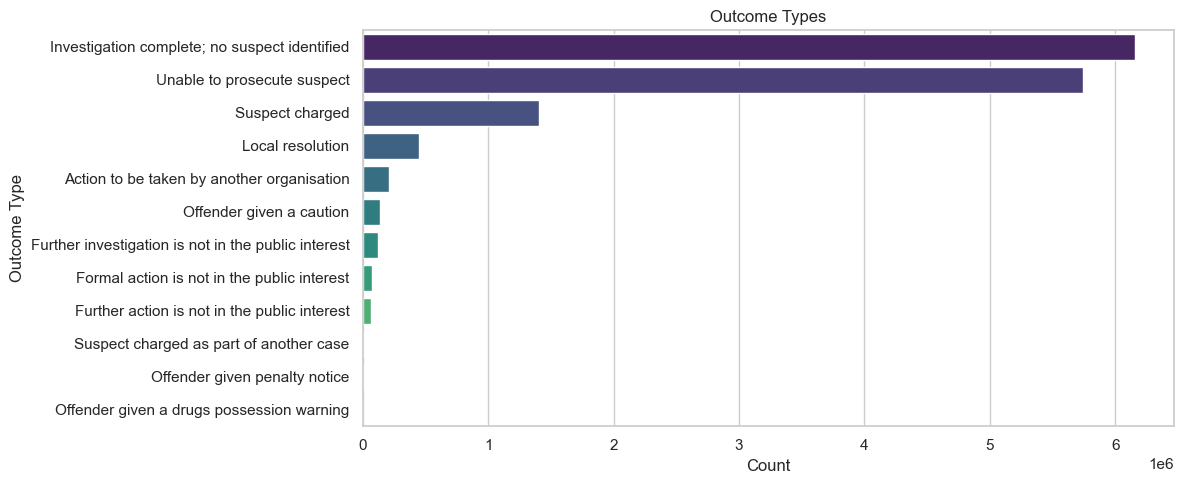

In [30]:
outcome_type_counts = top_counts(df_outcome, "Outcome type", n=20)
display(outcome_type_counts)
plot_top_counts(outcome_type_counts, "Outcome type", title="Outcome Types")


,Month,outcome_count,charged_count,charged_rate
0,2023-03-01,215531,13747,6.38
1,2023-04-01,298974,19272,6.45
2,2023-05-01,341553,22735,6.66
3,2023-06-01,356116,24351,6.84
4,2023-07-01,386245,27869,7.22
5,2023-08-01,402565,30509,7.58
6,2023-09-01,416684,32465,7.79
7,2023-10-01,469840,34692,7.38
8,2023-11-01,445047,36450,8.19
9,2023-12-01,398704,35108,8.81


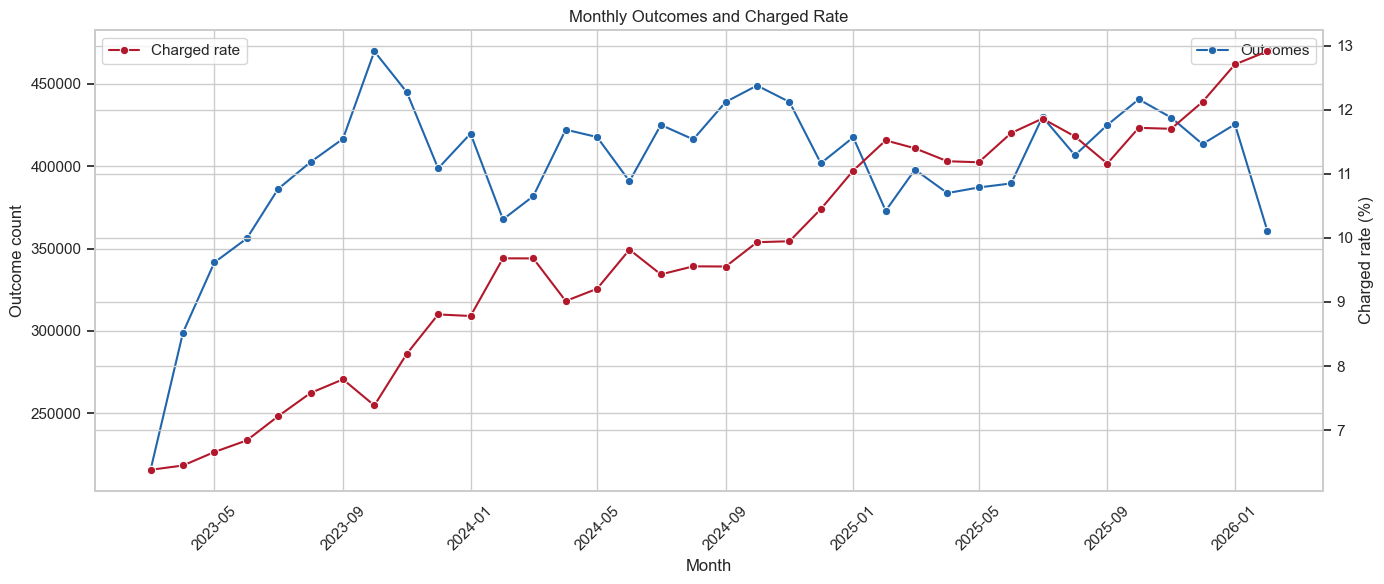

In [31]:
df_outcome["is_charged"] = df_outcome["Outcome type"].astype("string").str.contains("charged", case=False, na=False)

monthly_outcomes = (
    df_outcome.dropna(subset=["Month"])
    .groupby(pd.Grouper(key="Month", freq="MS"), observed=True)
    .agg(outcome_count=("Outcome type", "size"), charged_count=("is_charged", "sum"))
    .reset_index()
)
monthly_outcomes["charged_rate"] = monthly_outcomes["charged_count"] / monthly_outcomes["outcome_count"] * 100

display(monthly_outcomes)

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.lineplot(data=monthly_outcomes, x="Month", y="outcome_count", marker="o", ax=ax1, color="#2166ac", label="Outcomes")
ax1.set_ylabel("Outcome count")
ax2 = ax1.twinx()
sns.lineplot(data=monthly_outcomes, x="Month", y="charged_rate", marker="o", ax=ax2, color="#b2182b", label="Charged rate")
ax2.set_ylabel("Charged rate (%)")
ax1.set_title("Monthly Outcomes and Charged Rate")
ax1.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


we can see that the charge rate is increasing over time.

,Reported by,outcomes,charged,charged_rate
26,North Yorkshire Police,187608,31357,16.71
19,Lancashire Constabulary,477289,77333,16.20
28,Northumbria Police,273742,44118,16.12
24,Norfolk Constabulary,188533,29403,15.60
21,Lincolnshire Police,208641,29364,14.07
4,City of London Police,23028,3235,14.05
18,Kent Police,480325,66041,13.75
3,Cheshire Constabulary,238334,31248,13.11
6,Cumbria Constabulary,97448,12556,12.88
0,Avon and Somerset Constabulary,311666,39937,12.81


,Reported by,outcomes,charged,charged_rate
40,West Yorkshire Police,797732,73075,9.16
32,Staffordshire Police,255975,23008,8.99
20,Leicestershire Police,280148,24924,8.90
38,West Mercia Police,230303,19946,8.66
1,Bedfordshire Police,153212,13193,8.61
39,West Midlands Police,944972,80035,8.47
34,Surrey Police,211195,17484,8.28
13,Gloucestershire Constabulary,137640,11313,8.22
36,Thames Valley Police,495565,40484,8.17
11,Dyfed-Powys Police,94572,7644,8.08


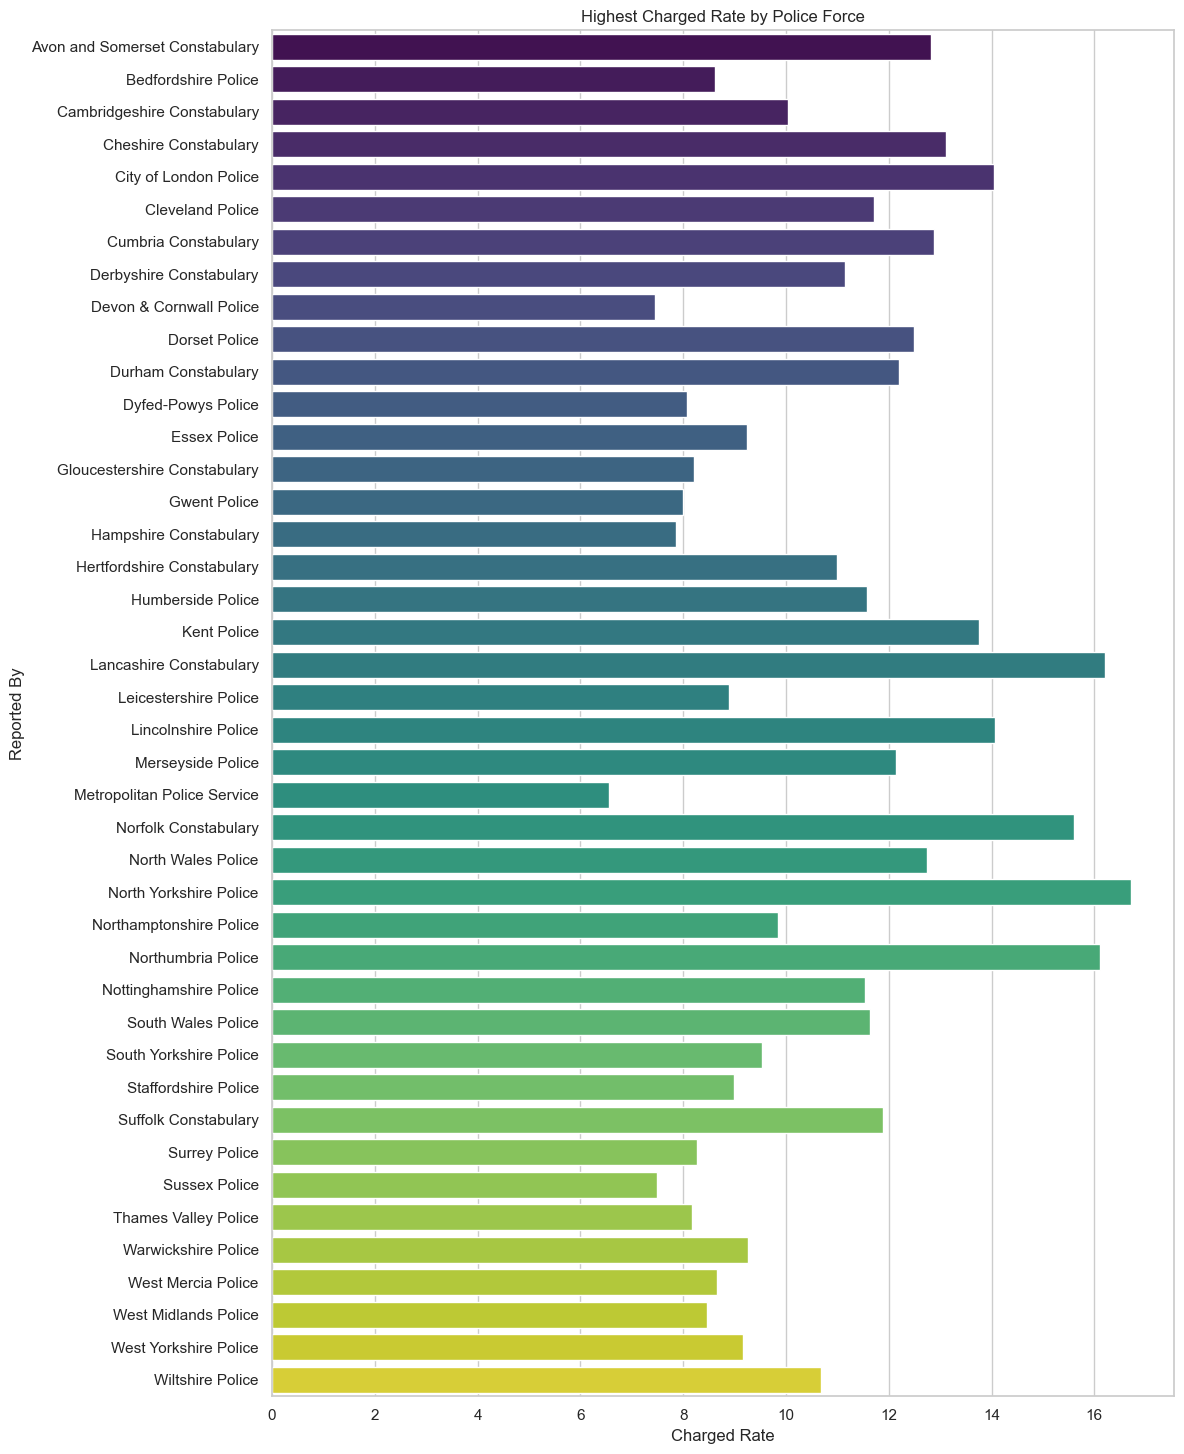

In [32]:
force_outcome_rates = (
    df_outcome.groupby("Reported by", observed=True)
    .agg(outcomes=("Outcome type", "size"), charged=("is_charged", "sum"))
    .reset_index()
)
force_outcome_rates["charged_rate"] = force_outcome_rates["charged"] / force_outcome_rates["outcomes"] * 100
force_outcome_rates = force_outcome_rates.sort_values("charged_rate", ascending=False)

display(force_outcome_rates.head(15))
display(force_outcome_rates.tail(15))

plot_top_counts(
    force_outcome_rates,
    "Reported by",
    "charged_rate",
    "Highest Charged Rate by Police Force",
)


## 5. Stop and Search Data



In [33]:
df_search = pd.read_csv(paths["stop_search"])
df_search["Date"] = pd.to_datetime(df_search["Date"], errors="coerce", utc=True)
df_search["Month"] = df_search["Date"].dt.tz_convert(None).dt.to_period("M").dt.to_timestamp()

for col in [
    "source_file",
    "Type",
    "Gender",
    "Age range",
    "Self-defined ethnicity",
    "Officer-defined ethnicity",
    "Legislation",
    "Object of search",
    "Outcome",
    "Outcome linked to object of search",
    "Removal of more than just outer clothing",
]:
    if col in df_search.columns:
        df_search[col] = df_search[col].astype("category")

for col in ["Longitude", "Latitude"]:
    df_search[col] = pd.to_numeric(df_search[col], errors="coerce")

print(f"Stop-and-search rows: {len(df_search):,}")
print(f"Stop-and-search columns: {df_search.shape[1]:,}")


Stop-and-search rows: 1,465,508
Stop-and-search columns: 17


In [34]:
display(df_search.head())

search_overview = pd.DataFrame(
    {
        "rows": [len(df_search)],
        "columns": [df_search.shape[1]],
        "start_month": [df_search["Month"].min()],
        "end_month": [df_search["Month"].max()],
        "months": [df_search["Month"].nunique()],
        "search_types": [df_search["Type"].nunique()],
        "objects_of_search": [df_search["Object of search"].nunique()],
        "outcomes": [df_search["Outcome"].nunique()],
    },
    index=["stop_search"],
)

display(search_overview.T.rename(columns={"stop_search": "value"}))


,source_file,Type,Date,Part of a policing operation,Policing operation,Latitude,Longitude,Gender,Age range,Self-defined ethnicity,Officer-defined ethnicity,Legislation,Object of search,Outcome,Outcome linked to object of search,Removal of more than just outer clothing,Month
0,2023-03-avon-and-somerset-stop-and-search.csv,Person search,2023-03-01 02:04:01+00:00,NaN,NaN,51.47,-2.56,Male,over 34,White - English/Welsh/Scottish/Northern Irish/...,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,NaN,False,2023-03-01
1,2023-03-avon-and-somerset-stop-and-search.csv,Person search,2023-03-01 02:07:37+00:00,NaN,NaN,51.43,-2.58,Male,18-24,White - English/Welsh/Scottish/Northern Irish/...,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,NaN,False,2023-03-01
2,2023-03-avon-and-somerset-stop-and-search.csv,Person search,2023-03-01 02:07:37+00:00,NaN,NaN,51.43,-2.58,Female,18-24,Other ethnic group - Not stated,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,NaN,False,2023-03-01
3,2023-03-avon-and-somerset-stop-and-search.csv,Person search,2023-03-01 02:07:37+00:00,NaN,NaN,51.43,-2.58,Female,18-24,White - English/Welsh/Scottish/Northern Irish/...,White,Police and Criminal Evidence Act 1984 (section 1),Articles for use in criminal damage,A no further action disposal,NaN,False,2023-03-01
4,2023-03-avon-and-somerset-stop-and-search.csv,Person search,2023-03-01 12:47:41+00:00,NaN,NaN,51.43,-2.58,Male,25-34,White - English/Welsh/Scottish/Northern Irish/...,White,Misuse of Drugs Act 1971 (section 23),Controlled drugs,A no further action disposal,NaN,False,2023-03-01


,value
rows,1465508
columns,17
start_month,2023-03-01 00:00:00
end_month,2026-02-01 00:00:00
months,36
search_types,3
objects_of_search,19
outcomes,7


#### Missing data

,column,missing_count,missing_percent
0,Policing operation,1465508,100.00
1,Part of a policing operation,650994,44.42
2,Outcome linked to object of search,617672,42.15
3,Removal of more than just outer clothing,376994,25.72
4,Age range,197445,13.47
5,Latitude,156355,10.67
6,Longitude,156355,10.67
7,Object of search,135779,9.26
8,Officer-defined ethnicity,121341,8.28
9,Self-defined ethnicity,97293,6.64


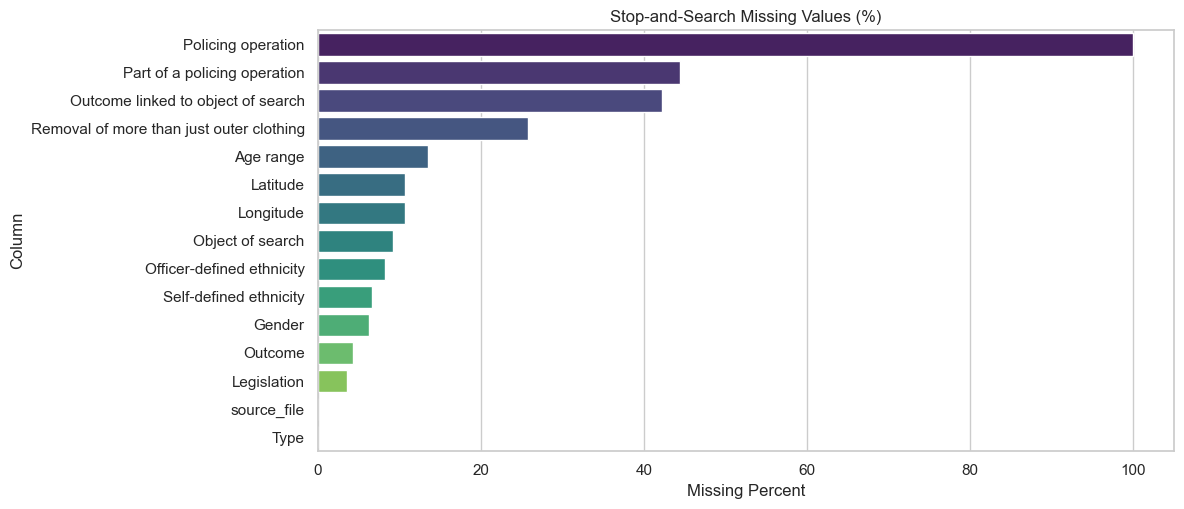

In [35]:
search_missing = missing_table(df_search)
display(search_missing)
plot_top_counts(search_missing.head(15), "column", "missing_percent", "Stop-and-Search Missing Values (%)")


#### grouping by and counting. 

,Gender,count,percent
0,Male,1171937,79.97
1,Female,161605,11.03
2,Missing,91535,6.25
3,Other,40431,2.76


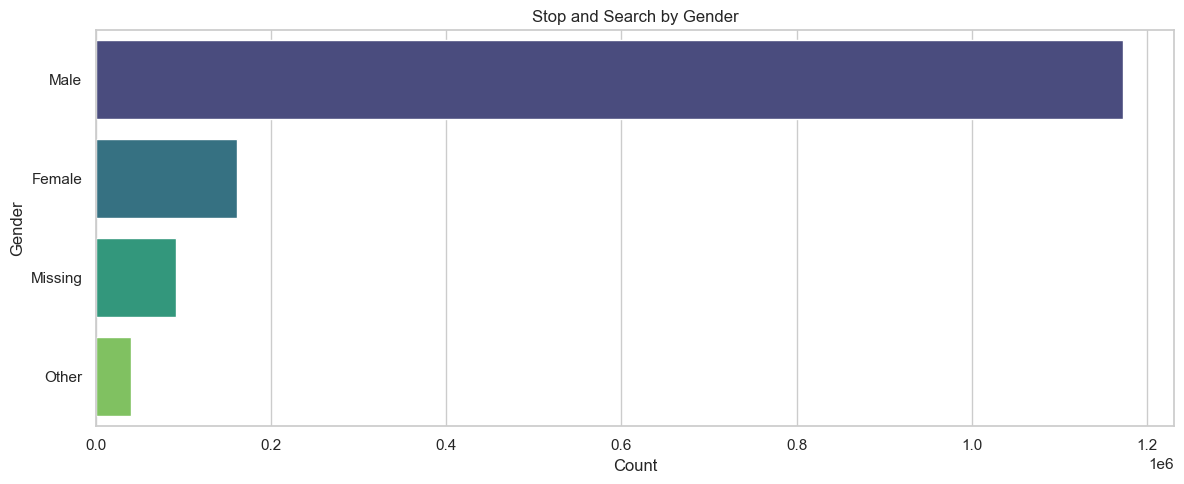

,Age range,count,percent
0,over 34,374507,25.55
1,18-24,351725,24.00
2,25-34,298254,20.35
3,10-17,242470,16.55
4,Missing,197445,13.47
5,under 10,1107,0.08


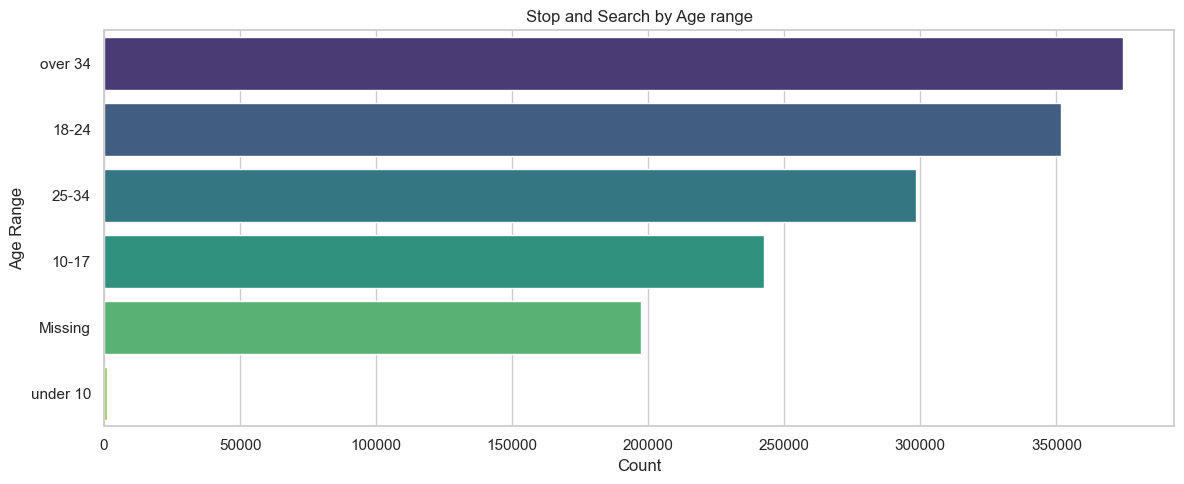

,Officer-defined ethnicity,count,percent
0,White,895273,61.09
1,Black,246714,16.83
2,Asian,151488,10.34
3,Missing,121341,8.28
4,Other,45723,3.12
5,Mixed,4969,0.34


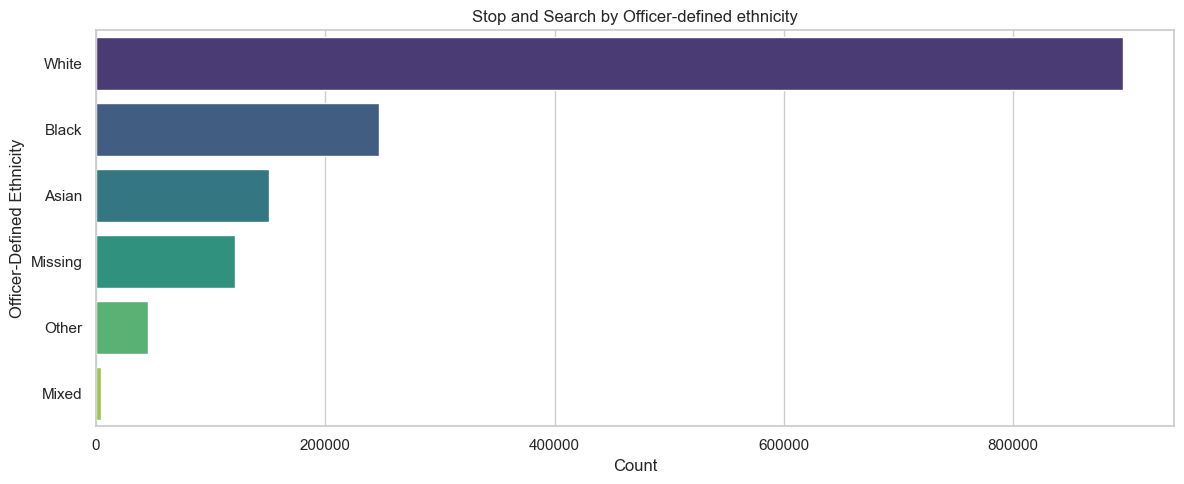

In [36]:
for column in ["Gender", "Age range", "Officer-defined ethnicity"]:
    table = top_counts(df_search, column, n=15)
    display(table)
    plot_top_counts(table, column, title=f"Stop and Search by {column}")


,Object of search,count,percent
0,Controlled drugs,813834,55.53
1,Offensive weapons,183925,12.55
2,Stolen goods,162126,11.06
3,Missing,135779,9.26
4,Article for use in theft,82981,5.66
5,Evidence of offences under the Act,23593,1.61
6,Anything to threaten or harm anyone,21706,1.48
7,Articles for use in criminal damage,19285,1.32
8,Firearms,11120,0.76
9,Fireworks,5061,0.35


,Outcome,count,percent
0,A no further action disposal,1002933,68.44
1,Arrest,215562,14.71
2,Community resolution,134906,9.21
3,Missing,63118,4.31
4,Summons / charged by post,24620,1.68
5,Penalty Notice for Disorder,13128,0.90
6,Caution (simple or conditional),6671,0.46
7,Khat or Cannabis warning,4570,0.31


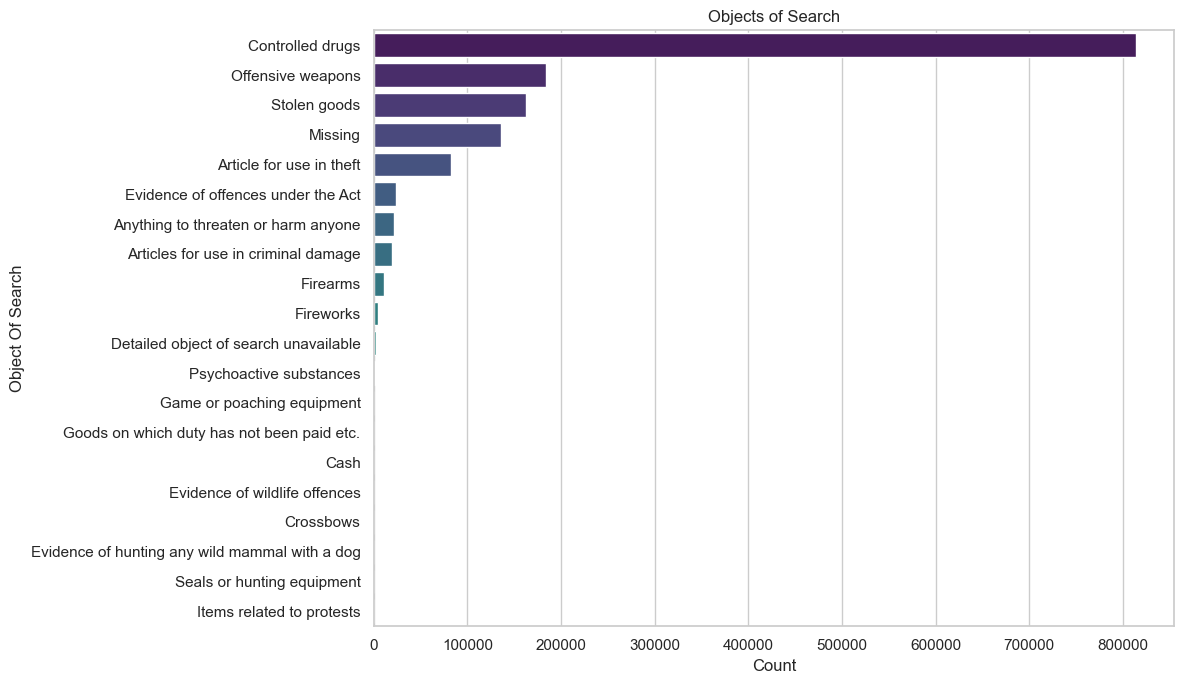

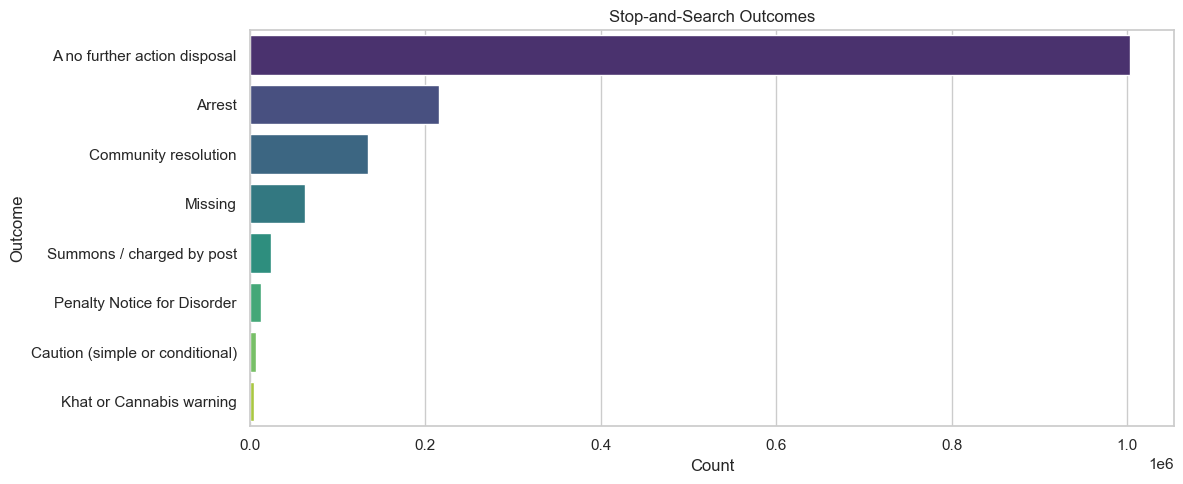

In [37]:
object_counts = top_counts(df_search, "Object of search", n=20)
search_outcome_counts = top_counts(df_search, "Outcome", n=20)

display(object_counts)
display(search_outcome_counts)

plot_top_counts(object_counts, "Object of search", title="Objects of Search")
plot_top_counts(search_outcome_counts, "Outcome", title="Stop-and-Search Outcomes")


#### positive stop and search outcomes 

In [38]:
outcome_text = df_search["Outcome"].astype("string")
positive_pattern = "arrest|caution|community resolution|penalty|summons|charged|khat|cannabis warning"
df_search["positive_outcome"] = outcome_text.str.contains(positive_pattern, case=False, regex=True, na=False)
df_search["no_further_action"] = outcome_text.str.contains("no further action", case=False, na=False)

search_outcome_summary = pd.DataFrame(
    {
        "metric": ["searches", "positive_outcomes", "no_further_action", "positive_rate"],
        "value": [
            len(df_search),
            df_search["positive_outcome"].sum(),
            df_search["no_further_action"].sum(),
            df_search["positive_outcome"].mean() * 100,
        ],
    }
)
display(search_outcome_summary)


,metric,value
0,searches,1465508.00
1,positive_outcomes,399457.00
2,no_further_action,1002933.00
3,positive_rate,27.26


In [39]:
def positive_rate_by(column: str, min_searches: int = 1_000) -> pd.DataFrame:
    rates = (
        df_search.groupby(column, dropna=False, observed=True)
        .agg(searches=("positive_outcome", "size"), positive_rate=("positive_outcome", "mean"))
        .reset_index()
    )
    rates["positive_rate"] = rates["positive_rate"] * 100
    return rates[rates["searches"] >= min_searches].sort_values("positive_rate", ascending=False)

for column in ["Object of search", "Gender", "Age range", "Officer-defined ethnicity"]:
    rates = positive_rate_by(column)
    print(column)
    display(rates.head(20))


Object of search


,Object of search,searches,positive_rate
18,Stolen goods,162126,34.06
4,Controlled drugs,813834,29.35
6,Detailed object of search unavailable,2915,27.00
10,Firearms,11120,24.76
8,Evidence of offences under the Act,23593,24.61
1,Article for use in theft,82981,23.02
15,Offensive weapons,183925,21.57
19,NaN,135779,21.52
16,Psychoactive substances,1829,20.50
2,Articles for use in criminal damage,19285,18.39


Gender


,Gender,searches,positive_rate
1,Male,1171937,27.94
3,NaN,91535,25.64
0,Female,161605,24.34
2,Other,40431,22.74


Age range


,Age range,searches,positive_rate
2,25-34,298254,33.39
1,18-24,351725,32.43
3,over 34,374507,27.98
4,under 10,1107,25.02
0,10-17,242470,19.90
5,NaN,197445,16.45


Officer-defined ethnicity


,Officer-defined ethnicity,searches,positive_rate
2,Mixed,4969,31.03
1,Black,246714,29.58
0,Asian,151488,29.28
3,Other,45723,28.15
4,White,895273,26.47
5,NaN,121341,25.31


,Month,search_count,positive_count,positive_rate
0,2023-03-01,45165,11568,25.61
1,2023-04-01,45713,11720,25.64
2,2023-05-01,42296,11045,26.11
3,2023-06-01,38326,10215,26.65
4,2023-07-01,43544,11440,26.27
5,2023-08-01,45057,11515,25.56
6,2023-09-01,37921,9897,26.10
7,2023-10-01,44545,11023,24.75
8,2023-11-01,38697,10083,26.06
9,2023-12-01,38274,10329,26.99


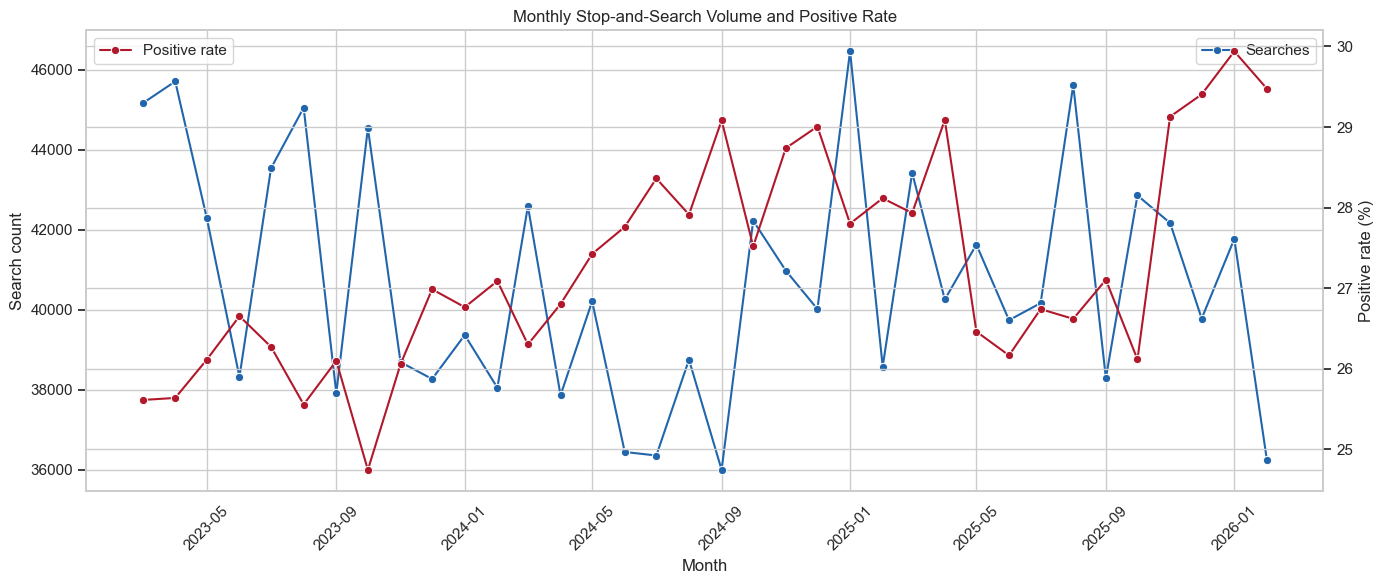

In [40]:
monthly_search = (
    df_search.dropna(subset=["Month"])
    .groupby(pd.Grouper(key="Month", freq="MS"), observed=True)
    .size()
    .rename("search_count")
    .reset_index()
)

monthly_search_positive = (
    df_search.dropna(subset=["Month"])
    .groupby(pd.Grouper(key="Month", freq="MS"), observed=True)
    .agg(search_count=("positive_outcome", "size"), positive_count=("positive_outcome", "sum"))
    .reset_index()
)
monthly_search_positive["positive_rate"] = monthly_search_positive["positive_count"] / monthly_search_positive["search_count"] * 100

display(monthly_search_positive)

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.lineplot(data=monthly_search_positive, x="Month", y="search_count", marker="o", ax=ax1, color="#2166ac", label="Searches")
ax1.set_ylabel("Search count")
ax2 = ax1.twinx()
sns.lineplot(data=monthly_search_positive, x="Month", y="positive_rate", marker="o", ax=ax2, color="#b2182b", label="Positive rate")
ax2.set_ylabel("Positive rate (%)")
ax1.set_title("Monthly Stop-and-Search Volume and Positive Rate")
ax1.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


## 6. Cross-Dataset Comparisons




,street_crimes,outcomes,stop_searches
Month,,,
2023-03-01,526084,215531,45165
2023-04-01,511229,298974,45713
2023-05-01,535333,341553,42296
2023-06-01,544532,356116,38326
2023-07-01,533581,386245,43544
2023-08-01,520941,402565,45057
2023-09-01,514173,416684,37921
2023-10-01,522786,469840,44545
2023-11-01,480849,445047,38697


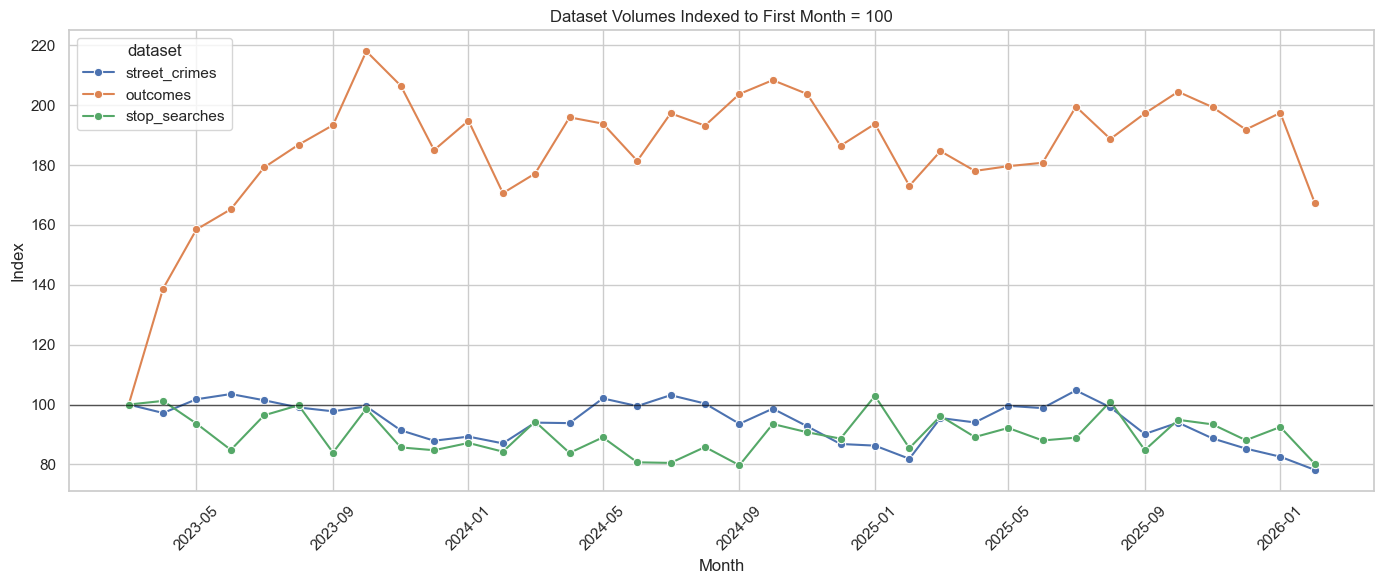

In [41]:
monthly_street = monthly_counts.set_index("Month")["crime_count"].rename("street_crimes")
monthly_outcome_series = monthly_outcomes.set_index("Month")["outcome_count"].rename("outcomes")
monthly_search_series = monthly_search.set_index("Month")["search_count"].rename("stop_searches")

monthly_comparison = pd.concat([monthly_street, monthly_outcome_series, monthly_search_series], axis=1).sort_index()
display(monthly_comparison)

base = monthly_comparison.replace(0, np.nan).iloc[0]
monthly_indexed = monthly_comparison.div(base).mul(100)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_indexed.reset_index().melt("Month", var_name="dataset", value_name="index_100"), x="Month", y="index_100", hue="dataset", marker="o")
plt.axhline(100, color="black", linewidth=1, alpha=0.6)
plt.title("Dataset Volumes Indexed to First Month = 100")
plt.xlabel("Month")
plt.ylabel("Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Save Key EDA Tables


In [42]:
output_dir = Path("eda_outputs")
output_dir.mkdir(exist_ok=True)

crime_type_counts.to_csv(output_dir / "crime_type_counts.csv", index=False)
monthly_counts.to_csv(output_dir / "monthly_street_crime_counts.csv", index=False)
force_counts.to_csv(output_dir / "force_counts.csv", index=False)
street_outcome_counts.to_csv(output_dir / "street_outcome_counts.csv", index=False)
outcome_type_counts.to_csv(output_dir / "outcome_type_counts.csv", index=False)
monthly_comparison.to_csv(output_dir / "monthly_dataset_comparison.csv")

print(f"Saved summary tables to: {output_dir.resolve()}")


Saved summary tables to: /Users/anas/PythonProjects/CBL/notebooks/eda_outputs
